# Plot `epednn_pure.py` outputs vs Oak's pedestal fits

`epednn_pure.py` runs EPED1-NN on each equilibrium in `EPEDNN_pure_output_v2/`, using
`neped` from Oak's fits, `zeffped` from the IDA `Zeff` profile, and `betan` from the
volume-averaged IDA kinetic pressure.

**Everything here is evaluated at one flux surface, `psiN_ped`** — the p_tot gradient
ped top from `pedestal_tops_summary_HighPerfHMode.csv`, which is the psi_N
`epednn_pure.py` uses for `neped` (with `ne_ped_psin = 'ped_top'`), `zeffped`, and
`psiN_ped_exp`.

That matters because `Oak_pedestal_fits.npy` stores each profile's pedestal value at
*that profile's own* gradient knee (`ped_eval_psin = grad_sym - grad_width/2`), and the
three knees do not coincide: over this set the n_e knee sits outboard of the p_tot knee
in 94% of cases (median +0.012 in psi_N, up to +0.20). Taking Oak's stored values
verbatim would divide a pressure from one radius by a density from another. So Oak's
fitted curves are re-evaluated at `psiN_ped` here, exactly as `epednn_pure.py` now does
for `neped`.

Three parity plots:

1. **Pressure** — Oak `p_tot` vs EPEDNN pedestal height, both at `psiN_ped`.
2. **Temperature, EPEDNN $n_e$ at $\psi_N = 1 - \Delta$** — $T_e = p / (2 n_e)$. The Oak
   reference uses $n_e(\psi_{N,\mathrm{ped}})$, the density fed to EPEDNN; the EPEDNN
   temperature uses $n_e$ at $1 - \Delta$, the pedestal top EPEDNN itself predicts.
3. **Temperature, both sides at $\psi_{N,\mathrm{ped}}$** — same reference, EPEDNN
   pressure converted with the same density it was handed. Only the EPEDNN-side density
   differs between plots 2 and 3.

$T_e = p / (2 n_e)$ assumes quasi-neutrality and $T_i = T_e$ — the same assumption
`epednn_pure.py` makes internally (`T_rat = 1`).

In [1]:
import csv
import io
import contextlib
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd().parent.parent          # saarelma-conner-ped/
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = Path('EPEDNN_pure_output_v3')
GFILE_FPS = '/mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/'
KPROF_FPS = '/mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/'
OAK_NPY = Path('Oak_pedestal_fits.npy')
OAK_CSV = ('/mnt/homes_global/jal2351/software/sc_inputs/'
           'pedestal_fits_snyder_short_Oak.csv')

E_CHARGE = 1.602176634e-19  # C

label_kw = dict(fontsize=14)
tick_labelsize = 12

## Load Oak fits and the EPEDNN outputs

In [2]:
# --- Oak's fitted curves, re-evaluatable at any psi_N --------------------------
# Oak_pedestal_fits.npy stores only ped_val_mean, i.e. each profile's fits evaluated at
# that profile's own knee. To put every quantity on one psi_N we reconstruct the fitted
# curves from the per-profile CSV. Same functional forms as sc_inputs/fit_pedestals.py
# (tnh0 / linfun) and the same "mean of the methods that converged" recipe, mirroring
# epednn_pure.oak_ne_at_psin.
OAK_PROFILES = ('n_e', 'T_e', 'p_tot')


def tnh0(c, x):
    """Modified tanh: c = [symmetry point, full width, height, offset, alpha]."""
    c = np.asarray(c, dtype=float)
    z = 2.0 * (c[0] - x) / c[1]
    pz = 1.0 + c[4] * z
    mth = 0.5 * ((pz + 1.0) * np.tanh(z) + pz - 1.0)
    return 0.5 * ((c[2] - c[3]) * mth + c[2] + c[3])


def linfun(c, x):
    """Two-line corner fit: c = [ped top psiN, ped top value, inner slope, outer slope]."""
    c = np.asarray(c, dtype=float)
    y = np.where(x <= c[0], c[2] * (c[0] - x) + c[1], c[3] * (x - c[0]) + c[1])
    return np.where(y < 0.0, 0.0, y)


def _f(row, key):
    v = (row.get(key) or '').strip()
    if not v or v.lower() == 'nan':
        return np.nan
    try:
        return float(v)
    except ValueError:
        return np.nan


def load_oak_fits(csv_path=OAK_CSV):
    """(shot, profile) -> list of fit records with the tanh / two-line parameters."""
    fits = defaultdict(list)
    with open(csv_path) as f:
        for row in csv.DictReader(f):
            prof = row.get('profile')
            if prof not in OAK_PROFILES or row.get('bad') in ('1', 'True', 'true'):
                continue
            tanh_c = [_f(row, k) for k in ('tanh_sym', 'tanh_width', 'tanh_height',
                                           'tanh_offset', 'tanh_alpha')]
            lin_c = [_f(row, k) for k in ('lin_top', 'lin_val',
                                          'lin_slope_in', 'lin_slope_out')]
            fits[(int(row['shot']), prof)].append({
                'time_ms': _f(row, 'time'),
                'knee': _f(row, 'ped_eval_psin'),        # this profile's own psi_N
                'ped_val_mean': _f(row, 'ped_val_mean'), # value AT that knee
                'tanh': tanh_c if (row.get('tanh_ok') == '1'
                                   and np.all(np.isfinite(tanh_c))) else None,
                'lin': lin_c if (row.get('lin_ok') == '1'
                                 and np.all(np.isfinite(lin_c))) else None,
                'grad_ok': row.get('grad_ok') == '1',
            })
    return fits


def oak_fit_for_tag(equil_tag, profile, fits):
    """Fit record for g-file tag '125729.03589': same shot, closest time."""
    shot_s, time_s = equil_tag.split('.', 1)
    rows = fits.get((int(shot_s), profile))
    if not rows:
        return None
    return min(rows, key=lambda r: abs(r['time_ms'] - float(time_s)))


def oak_val_at(fit, psin, psi_prof, prof_vals):
    """Oak's pedestal value at an arbitrary psi_N: mean of the converged methods.

    The gradient method has no closed form -- it is the measured profile itself, so it
    enters as an interpolation of the corresponding measured profile.
    """
    if fit is None or not np.isfinite(psin):
        return np.nan
    vals = []
    if fit['tanh'] is not None:
        vals.append(float(tnh0(fit['tanh'], np.asarray([psin], dtype=float))[0]))
    if fit['grad_ok'] and psi_prof is not None:
        vals.append(float(np.interp(psin, psi_prof, prof_vals)))
    if fit['lin'] is not None:
        vals.append(float(linfun(fit['lin'], np.asarray([psin], dtype=float))[0]))
    return float(np.mean(vals)) if vals else np.nan


oak_fits = load_oak_fits()
print(f'Loaded Oak fits: '
      + ', '.join(f'{p} for {sum(1 for k in oak_fits if k[1] == p)} shots'
                  for p in OAK_PROFILES))

# The stored (per-profile-knee) values, kept only to show what changes.
oak = np.load(OAK_NPY, allow_pickle=True).item()
oak_tags = [str(t) for t in oak['equil_shotandtime']]   # '125729.3589.5480'
oak_n_e = np.asarray(oak['n_e'], dtype=float)           # m^-3, at the n_e knee
oak_T_e = np.asarray(oak['T_e'], dtype=float)           # eV,   at the T_e knee
oak_p_tot = np.asarray(oak['p_tot'], dtype=float)       # Pa,   at the p_tot knee


def oak_index_for_tag(equil_tag):
    """Oak row index for a g-file tag '125729.03589': same shot, closest time."""
    shot_s, time_s = equil_tag.split('.', 1)
    shot, time_ms = int(shot_s), float(time_s)
    best_i, best_dt = None, None
    for i_oak, tag_oak in enumerate(oak_tags):
        s_oak, t_oak = tag_oak.split('.', 1)
        if int(s_oak) != shot:
            continue
        dt = abs(float(t_oak) - time_ms)
        if best_dt is None or dt < best_dt:
            best_dt, best_i = dt, i_oak
    return best_i


# How far apart the three knees are, for reference. Oak tags are already
# 'shot.time' once split at the first dot, so they work as lookup keys directly.
for p in OAK_PROFILES:
    a = np.array([(oak_fit_for_tag(t, p, oak_fits) or {}).get('knee', np.nan)
                  for t in oak_tags])
    print(f'  ped_eval_psin ({p:5s}): median {np.nanmedian(a):.4f}  '
          f'range [{np.nanmin(a):.4f}, {np.nanmax(a):.4f}]')

Loaded Oak fits: n_e for 214 shots, T_e for 214 shots, p_tot for 212 shots
  ped_eval_psin (n_e  ): median 0.9598  range [0.8600, 0.9879]
  ped_eval_psin (T_e  ): median 0.9494  range [0.8547, 0.9782]
  ped_eval_psin (p_tot): median 0.9457  range [0.7695, 0.9773]


In [3]:
# --- EPEDNN outputs ------------------------------------------------------------
records = []
n_skip = 0
for entry in sorted(OUT_DIR.glob('*.npy')):
    d = np.load(entry, allow_pickle=True).item()
    tag = entry.stem                       # '125729.03589'
    i_oak = oak_index_for_tag(tag)
    if i_oak is None:
        n_skip += 1
        continue
    # psiN_neped is written by epednn_pure.py alongside neped; older outputs that
    # predate it took neped at Oak's n_e knee, so fall back to that.
    psiN_neped = d.get('psiN_neped')
    records.append({
        'tag': tag,
        'p_eped': float(d['pedestal_height']) * 1e6,   # MPa -> Pa
        'width': float(d['pedestal_width']),           # psi_N
        'betan': float(np.ravel(d['betan'])[0]),
        'psiN_ped': float(d['psiN_ped_exp']),          # p_tot ped top, the common psi_N
        'psiN_neped': float(psiN_neped) if psiN_neped is not None else np.nan,
        'ne_ped_eped_in': float(d['ne_ped_1e19']) * 1e19,  # m^-3, the neped fed to EPEDNN
        'zeff_ped': float(d['zeff_ped']),
        # measured total pressure profile, needed for the gradient member of Oak's p_tot
        'psi_p_prof': np.asarray(d['psiN_kfilepres'], dtype=float),
        'p_prof': np.asarray(d['kfile_pres'], dtype=float),
        'i_oak': i_oak,
        # legacy per-knee values, for the before/after comparison only
        'p_oak_knee': oak_p_tot[i_oak],                # Pa,   at the p_tot knee
        'ne_oak_knee': oak_n_e[i_oak],                 # m^-3, at the n_e knee
        'Te_oak_knee': oak_T_e[i_oak],                 # eV,   at the T_e knee
    })

print(f'Loaded {len(records)} EPEDNN cases from {OUT_DIR} (skipped {n_skip} without an Oak match)')
w = np.array([r['width'] for r in records])
print(f'EPEDNN pedestal width Delta: median {np.median(w):.4f}, '
      f'range [{w.min():.4f}, {w.max():.4f}]  ->  psi_N = 1 - Delta in '
      f'[{1 - w.max():.4f}, {1 - w.min():.4f}]')

_pn = np.array([r['psiN_neped'] for r in records])
if np.all(np.isnan(_pn)):
    print('\nWARNING: these outputs predate psiN_neped -- they were made with neped at '
          "Oak's n_e knee, not at psiN_ped. Re-run epednn_pure.py "
          "(ne_ped_psin = 'ped_top') for the consistent comparison below.")
else:
    off = np.abs(_pn - np.array([r['psiN_ped'] for r in records]))
    print(f'\nneped evaluated at psiN_ped in {np.sum(off < 1e-9)}/{len(records)} cases '
          f'(max |psiN_neped - psiN_ped| = {np.nanmax(off):.2e})')

Loaded 1 EPEDNN cases from EPEDNN_pure_output_v3 (skipped 0 without an Oak match)
EPEDNN pedestal width Delta: median 0.0389, range [0.0389, 0.0389]  ->  psi_N = 1 - Delta in [0.9611, 0.9611]

neped evaluated at psiN_ped in 1/1 cases (max |psiN_neped - psiN_ped| = 0.00e+00)


## Measured $n_e$ and $T_e$ profiles from the IDA files

`epednn_pure.py` saves the total pressure profile but not $n_e$ / $T_e$, so read those
back out of the same OMFITnc `.cdf` files, using the same g-file to `.cdf` pairing
(`initialize_inputs`) the run used. They are needed twice: to evaluate $n_e$ at
$\psi_N = 1 - \Delta$, and as the gradient member of Oak's $n_e$ / $T_e$ fits.

The first pass is slow (302 files through `OMFITnc`); results are cached to
`ida_profiles_cache.npz`, so delete that file to force a re-read.

In [4]:
PROF_CACHE = Path('ida_profiles_cache.npz')


def _reduce_time(arr):
    """Average over a leading time axis if present."""
    arr = np.asarray(arr, dtype=float)
    return np.mean(arr, axis=0) if arr.ndim > 1 else arr


def _nc_array(nc, name):
    var = nc[name]
    if hasattr(var, 'keys') and 'data' in var:
        return np.asarray(var['data'], dtype=float)
    return np.asarray(var, dtype=float)


def build_prof_cache():
    """tag -> (psi_N, n_e [m^-3], T_e [eV]), sorted and de-duplicated.

    Matches the handling in epednn_pure.OMFITnc_load (clip to psi_N in [0, 1], drop
    duplicate psi points, same eV/keV unit heuristic) but skips the parts only needed
    for pressure/Zeff.
    """
    from omfit_classes.omfit_nc import OMFITnc
    from src.load_equil import initialize_inputs

    equil_num = len(list(Path(KPROF_FPS).glob('*.cdf')))
    with contextlib.redirect_stdout(io.StringIO()):   # initialize_inputs is chatty
        equilibria = initialize_inputs(equil_num, GFILE_FPS, KPROF_FPS, p_filetype='OMFITnc')

    cache = {}
    for k, (mhd_fp, kprof_fp) in enumerate(equilibria):
        tag = Path(mhd_fp).name[1:]
        nc = OMFITnc(kprof_fp)
        ne = _reduce_time(_nc_array(nc, 'n_e')).ravel()

        Te = _reduce_time(_nc_array(nc, 'T_e')).ravel()   # keep in eV
        te_unit = ''
        if hasattr(nc['T_e'], 'keys') and 'unit' in nc['T_e']:
            te_unit = str(nc['T_e']['unit']).lower()
        if te_unit in ('kev',):
            Te = Te * 1e3
        elif te_unit in ('ev', 'electron volt', 'electron-volt'):
            pass
        elif np.nanmax(np.abs(Te)) < 100:   # looks like keV
            Te = Te * 1e3

        for psi_key in ('psi_n', 'psi_N', 'psiN', 'psin'):
            if psi_key in nc:
                break
        else:
            raise KeyError(f'No psi_N grid in {kprof_fp}')
        psi = _reduce_time(_nc_array(nc, psi_key)).ravel()

        order = np.argsort(psi)
        psi, ne, Te = psi[order], ne[order], Te[order]
        mask = (psi >= 0.0) & (psi <= 1.0)
        if np.count_nonzero(mask) < 2:
            mask = np.ones_like(psi, dtype=bool)
        _, uniq = np.unique(psi[mask], return_index=True)
        uniq = np.sort(uniq)
        cache[f'{tag}|psi'] = psi[mask][uniq]
        cache[f'{tag}|ne'] = ne[mask][uniq]
        cache[f'{tag}|Te'] = Te[mask][uniq]
        if (k + 1) % 50 == 0:
            print(f'  read {k + 1}/{len(equilibria)}')

    np.savez_compressed(PROF_CACHE, **cache)
    print(f'Cached {len(equilibria)} profiles to {PROF_CACHE}')
    return cache


if PROF_CACHE.exists():
    with np.load(PROF_CACHE) as z:
        prof_cache = {k: z[k] for k in z.files}
    print(f'Loaded {len(prof_cache) // 3} cached profiles from {PROF_CACHE}')
else:
    prof_cache = build_prof_cache()

Loaded 302 cached profiles from ida_profiles_cache.npz


In [5]:
# --- Put every pedestal quantity on psiN_ped -----------------------------------
n_missing = 0
for r in records:
    psi = prof_cache.get(f"{r['tag']}|psi")
    ne_prof = prof_cache.get(f"{r['tag']}|ne")
    Te_prof = prof_cache.get(f"{r['tag']}|Te")
    if psi is None:
        n_missing += 1

    psin = r['psiN_ped']
    fit_ne = oak_fit_for_tag(r['tag'], 'n_e', oak_fits)
    fit_Te = oak_fit_for_tag(r['tag'], 'T_e', oak_fits)
    fit_pt = oak_fit_for_tag(r['tag'], 'p_tot', oak_fits)

    # Oak's fits, all re-evaluated at the common ped top.
    r['ne_at_ped'] = oak_val_at(fit_ne, psin, psi, ne_prof)                    # m^-3
    r['Te_oak_at_ped'] = oak_val_at(fit_Te, psin, psi, Te_prof)               # eV
    r['p_oak_at_ped'] = oak_val_at(fit_pt, psin, r['psi_p_prof'], r['p_prof'])  # Pa

    # Density at the pedestal top EPEDNN itself predicts (plot 2 only).
    r['psin_1mw'] = 1.0 - r['width']
    r['ne_at_1mw'] = (float(np.interp(r['psin_1mw'], psi, ne_prof))
                      if psi is not None else np.nan)

ne_ped = np.array([r['ne_at_ped'] for r in records])          # m^-3, at psiN_ped
ne_1mw = np.array([r['ne_at_1mw'] for r in records])          # m^-3, at 1 - Delta
ne_in = np.array([r['ne_ped_eped_in'] for r in records])      # m^-3, fed to EPEDNN
ne_knee = np.array([r['ne_oak_knee'] for r in records])       # m^-3, at the n_e knee

print(f'n_e at psiN_ped:   median {np.nanmedian(ne_ped):.3e} m^-3 '
      f'({n_missing} cases without a cached profile)')
print(f'n_e at 1-Delta:    median {np.nanmedian(ne_1mw):.3e} m^-3')
print(f'ratio n_e(1-Delta) / n_e(psiN_ped): median {np.nanmedian(ne_1mw / ne_ped):.3f}')
print(f'ratio n_e(psiN_ped) / n_e(Oak n_e knee): '
      f'median {np.nanmedian(ne_ped / ne_knee):.3f}  '
      f'(5-95%: {np.nanpercentile(ne_ped / ne_knee, 5):.3f} - '
      f'{np.nanpercentile(ne_ped / ne_knee, 95):.3f})')

# Cross-check: this notebook and epednn_pure.py should agree on the density EPEDNN got.
# Not bit-identical -- the gradient member interpolates the raw cached profile here, while
# epednn_pure.OMFITnc_load first cubic-resamples n_e onto a uniform psi_N grid -- so a few
# 1e-5 is expected. Anything percent-level means the two are on different psi_N.
ok = np.isfinite(ne_ped) & np.isfinite(ne_in)
rel = np.abs(ne_ped[ok] - ne_in[ok]) / ne_in[ok]
print(f'\nCheck vs the neped epednn_pure.py actually used: max rel. diff = {rel.max():.2e}'
      + ('  OK (resampling noise)' if rel.max() < 5e-3 else
         "  <-- MISMATCH: re-run epednn_pure.py with ne_ped_psin = 'ped_top'"))

n_e at psiN_ped:   median 3.086e+19 m^-3 (0 cases without a cached profile)
n_e at 1-Delta:    median 2.889e+19 m^-3
ratio n_e(1-Delta) / n_e(psiN_ped): median 0.936
ratio n_e(psiN_ped) / n_e(Oak n_e knee): median 1.107  (5-95%: 1.107 - 1.107)

Check vs the neped epednn_pure.py actually used: max rel. diff = 1.40e-05  OK (resampling noise)


## Parity-plot helper

In [6]:
def parity_plot(x, y, xlabel, ylabel, lim=None, pm=20, color='tab:red', title=None,
                tags=None, within=5.0, list_within=True, max_list=None):
    """Scatter y vs x with a 1:1 line and a +/-pm% band; prints agreement stats.

    lim=None auto-scales both axes to the data (square, starting at 0).

    Cases falling within +/-`within` percent of y = x are highlighted and listed by
    case number (index into `records`) and equilibrium tag. `tags` should be the
    per-case tag list, aligned with x and y before any nan filtering.

    Returns
    -------
    fig, ax, close : the figure, its axes, and a dict with the near-1:1 cases
        ('case_no', 'tag', 'x', 'y', 'ratio' arrays, all sorted by |ratio - 1|).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    case_no = np.arange(x.size)
    tags = np.asarray(tags if tags is not None else [''] * x.size)

    good = np.isfinite(x) & np.isfinite(y)
    x, y, case_no, tags = x[good], y[good], case_no[good], tags[good]
    if lim is None:
        lim = (0.0, 1.05 * max(x.max(), y.max()))

    ratio = y / x
    close_mask = np.abs(ratio - 1.0) <= within / 100.0

    fig, ax = plt.subplots(figsize=(5.2, 5.0))
    x_line = np.linspace(*lim, 200)
    ax.fill_between(x_line, (1 - pm / 100) * x_line, (1 + pm / 100) * x_line,
                    color='0.75', alpha=0.35, label=fr'$\pm {pm:g}\%$', zorder=0)
    ax.plot(x_line, x_line, 'k--', zorder=1)
    ax.plot(x[~close_mask], y[~close_mask], 'o', color=color, ms=4, alpha=0.75, zorder=2)
    ax.plot(x[close_mask], y[close_mask], 'o', color=color, ms=6,
            markeredgecolor='k', markeredgewidth=0.8, zorder=3,
            label=fr'within $\pm {within:g}\%$ ({close_mask.sum()})')

    ax.set_xlabel(xlabel, **label_kw)
    ax.set_ylabel(ylabel, **label_kw)
    ax.set_xlim(*lim)
    ax.set_ylim(*lim)
    ax.tick_params('both', labelsize=tick_labelsize)
    ax.legend(loc='upper left', fontsize=tick_labelsize)
    if title:
        ax.set_title(title, fontsize=tick_labelsize + 1)
    fig.tight_layout()

    frac_in = np.mean(np.abs(ratio - 1) <= pm / 100)
    print(f'N = {x.size}   median y/x = {np.median(ratio):.3f}   '
          f'mean y/x = {np.mean(ratio):.3f}   within +/-{pm:g}%: {100 * frac_in:.0f}%   '
          f'RMS frac. error = {np.sqrt(np.mean((ratio - 1) ** 2)):.3f}')

    order = np.argsort(np.abs(ratio[close_mask] - 1.0))
    close = {
        'case_no': case_no[close_mask][order],
        'tag': tags[close_mask][order],
        'x': x[close_mask][order],
        'y': y[close_mask][order],
        'ratio': ratio[close_mask][order],
    }

    if list_within:
        n_close = close['case_no'].size
        print(f'\n{n_close} / {x.size} cases within +/-{within:g}% of y = x '
              f'({100 * n_close / x.size:.0f}%), best first:')
        shown = n_close if max_list is None else min(n_close, max_list)
        for k in range(shown):
            print(f"  case {close['case_no'][k]:>3d}  {close['tag'][k]:<14s}  "
                  f"x = {close['x'][k]:8.1f}   y = {close['y'][k]:8.1f}   "
                  f"y/x = {close['ratio'][k]:.3f}")
        if shown < n_close:
            print(f'  ... {n_close - shown} more (raise max_list to see them)')

    return fig, ax, close

## 1. Pedestal pressure: Oak $p_\mathrm{tot}$ vs EPEDNN

EPEDNN's `pedestal_height` is a total pressure, so it is compared against Oak's `p_tot`
fits evaluated at `psiN_ped`.

Oak p_tot at psiN_ped vs at its own knee: median ratio 0.971

N = 1   median y/x = 0.932   mean y/x = 0.932   within +/-20%: 100%   RMS frac. error = 0.068

0 / 1 cases within +/-2% of y = x (0%), best first:


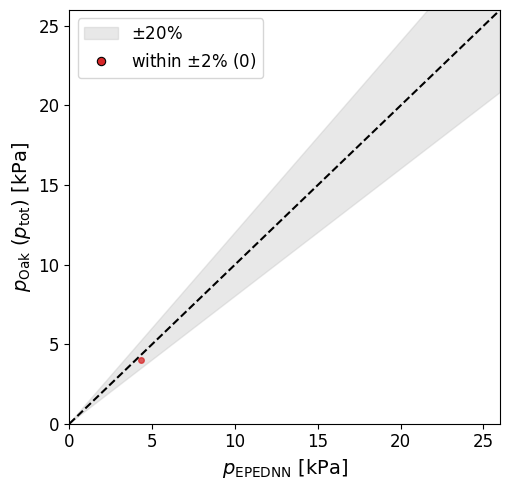

In [7]:
p_eped = np.array([r['p_eped'] for r in records])            # Pa
p_oak = np.array([r['p_oak_at_ped'] for r in records])      # Pa, Oak p_tot at psiN_ped
p_oak_knee = np.array([r['p_oak_knee'] for r in records])   # Pa, at Oak's own p_tot knee
case_tags = [r['tag'] for r in records]                     # case number == index into records

print(f'Oak p_tot at psiN_ped vs at its own knee: '
      f'median ratio {np.nanmedian(p_oak / p_oak_knee):.3f}\n')

_, _, close_p = parity_plot(
    p_eped / 1e3, p_oak / 1e3,
    xlabel=r'$p_\mathrm{EPEDNN}$ [kPa]',
    ylabel=r'$p_\mathrm{Oak}$ ($p_\mathrm{tot}$) [kPa]',
    lim=(0, 26),
    tags=case_tags,
    within=2,          # percent of the y = x line
)
plt.show()

## 2. Pedestal temperature, EPEDNN side using $n_e$ at $\psi_N = 1 - \Delta$

$T_e = p / (2 n_e)$ on both axes, but the two sides use different densities:

- **Oak (y):** $p_\mathrm{tot}(\psi_{N,\mathrm{ped}}) / (2 n_e(\psi_{N,\mathrm{ped}}) e)$ --
  pressure and density from the same flux surface, the one EPEDNN was fed. Fixed for both
  $T_e$ plots.
- **EPEDNN (x):** $n_e$ read from the IDA profile at $\psi_N = 1 - \Delta$, with $\Delta$
  the EPEDNN pedestal width for that case -- the density at the pedestal top EPEDNN itself
  predicts, rather than the one it was handed.

N = 1   median y/x = 0.872   mean y/x = 0.872   within +/-20%: 100%   RMS frac. error = 0.128

0 / 1 cases within +/-5% of y = x (0%), best first:


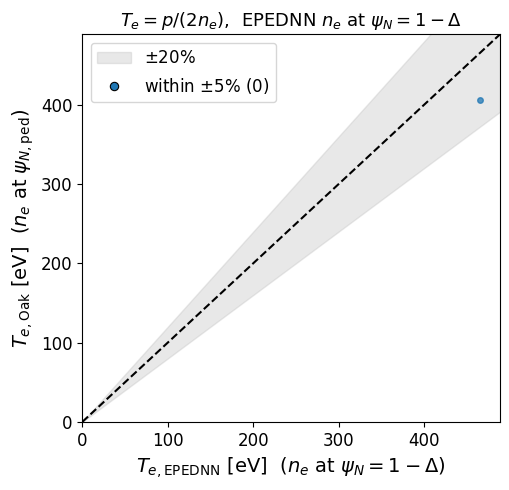

In [8]:
# Oak reference temperature: Oak pressure and density, both at psiN_ped.
Te_oak_ref = p_oak / (2.0 * ne_ped * E_CHARGE)         # eV
Te_eped_1mw = p_eped / (2.0 * ne_1mw * E_CHARGE)       # eV, EPEDNN p with n_e(1 - Delta)

_, _, close_Te_1mw = parity_plot(
    Te_eped_1mw, Te_oak_ref,
    xlabel=r'$T_{e,\mathrm{EPEDNN}}$ [eV]  ($n_e$ at $\psi_N = 1 - \Delta$)',
    ylabel=r'$T_{e,\mathrm{Oak}}$ [eV]  ($n_e$ at $\psi_{N,\mathrm{ped}}$)',
    color='tab:blue',
    title=r'$T_e = p / (2 n_e)$,  EPEDNN $n_e$ at $\psi_N = 1 - \Delta$',
    tags=case_tags,
    within=5,          # percent of the y = x line
)
plt.show()

## 3. Pedestal temperature, both sides at $\psi_{N,\mathrm{ped}}$

Same reference on the y axis, but the EPEDNN pressure is now converted with the *same*
density it was fed. Both axes then share one density, so this panel is the pressure plot
rescaled point-by-point by $1 / (2 n_e e)$ and its ratio statistics match plot 1 exactly.
The difference between plots 2 and 3 is purely the EPEDNN-side density choice.

N = 1   median y/x = 0.932   mean y/x = 0.932   within +/-20%: 100%   RMS frac. error = 0.068

0 / 1 cases within +/-1% of y = x (0%), best first:


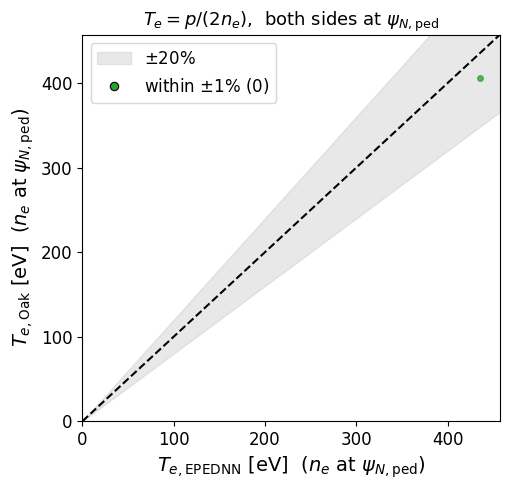


Check vs Oak fitted T_e at psiN_ped: median [p_tot/(2 n_e)] / T_e,Oak = 0.946  (N = 1)
  for comparison, vs Oak T_e at its own knee: 0.949
median T_e,EPEDNN(1-Delta) / T_e,EPEDNN(psiN_ped) = 1.068

Cases within +/-5% in all three plots (0): 


In [9]:
Te_eped_ped = p_eped / (2.0 * ne_ped * E_CHARGE)        # eV, EPEDNN p with the fed n_e

_, _, close_Te_ped = parity_plot(
    Te_eped_ped, Te_oak_ref,
    xlabel=r'$T_{e,\mathrm{EPEDNN}}$ [eV]  ($n_e$ at $\psi_{N,\mathrm{ped}}$)',
    ylabel=r'$T_{e,\mathrm{Oak}}$ [eV]  ($n_e$ at $\psi_{N,\mathrm{ped}}$)',
    color='tab:green',
    title=r'$T_e = p / (2 n_e)$,  both sides at $\psi_{N,\mathrm{ped}}$',
    tags=case_tags,
    within=1,          # percent of the y = x line
)
plt.show()

# Sanity check: with p_tot and n_e now taken on the same flux surface, the derived Oak
# reference should track Oak's own fitted T_e there. (Taking each at its own knee used to
# bias this ratio ~4% high.)
Te_oak_at_ped = np.array([r['Te_oak_at_ped'] for r in records])
Te_oak_knee = np.array([r['Te_oak_knee'] for r in records])
ok = np.isfinite(Te_oak_ref) & np.isfinite(Te_oak_at_ped)
print(f'\nCheck vs Oak fitted T_e at psiN_ped: median [p_tot/(2 n_e)] / T_e,Oak = '
      f'{np.median(Te_oak_ref[ok] / Te_oak_at_ped[ok]):.3f}  (N = {ok.sum()})')
ok2 = np.isfinite(Te_oak_ref) & np.isfinite(Te_oak_knee)
print(f'  for comparison, vs Oak T_e at its own knee: '
      f'{np.median(Te_oak_ref[ok2] / Te_oak_knee[ok2]):.3f}')

# How much the EPEDNN-side density choice moves the comparison
print(f'median T_e,EPEDNN(1-Delta) / T_e,EPEDNN(psiN_ped) = '
      f'{np.nanmedian(Te_eped_1mw / Te_eped_ped):.3f}')

# Cases that sit near y = x in every panel
common = (set(close_p['case_no'].tolist())
          & set(close_Te_1mw['case_no'].tolist())
          & set(close_Te_ped['case_no'].tolist()))
print(f'\nCases within +/-5% in all three plots ({len(common)}): '
      + ', '.join(f'{c} ({records[c]["tag"]})' for c in sorted(common)))

In [10]:
print('Te EPEDNN: ',Te_eped_ped)
print('Te Oak: ',Te_oak_ref)
print('psiN ped: ',r['psiN_ped'])

Te EPEDNN:  [435.5968504]
Te Oak:  [405.94632033]
psiN ped:  0.93963915
